<a href="https://colab.research.google.com/github/NischalGrg5555/AI-Level-6/blob/main/Worksheet_5_Nischal_Gurung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nischal Gurung - Workshop 5


**Implement an End to End CNN Model for Image Classification Task.**

**Task 1: Data Understanding and Visualization:**



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt
import random
import cv2
import numpy as np

In [ ]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/AI/Week5/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI/Week5/FruitinAmazon/test"

**1) Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.**

In [ ]:
classes = sorted(os.listdir(train_dir))
classes = [cls for cls in classes if os.path.isdir(os.path.join(train_dir, cls))]

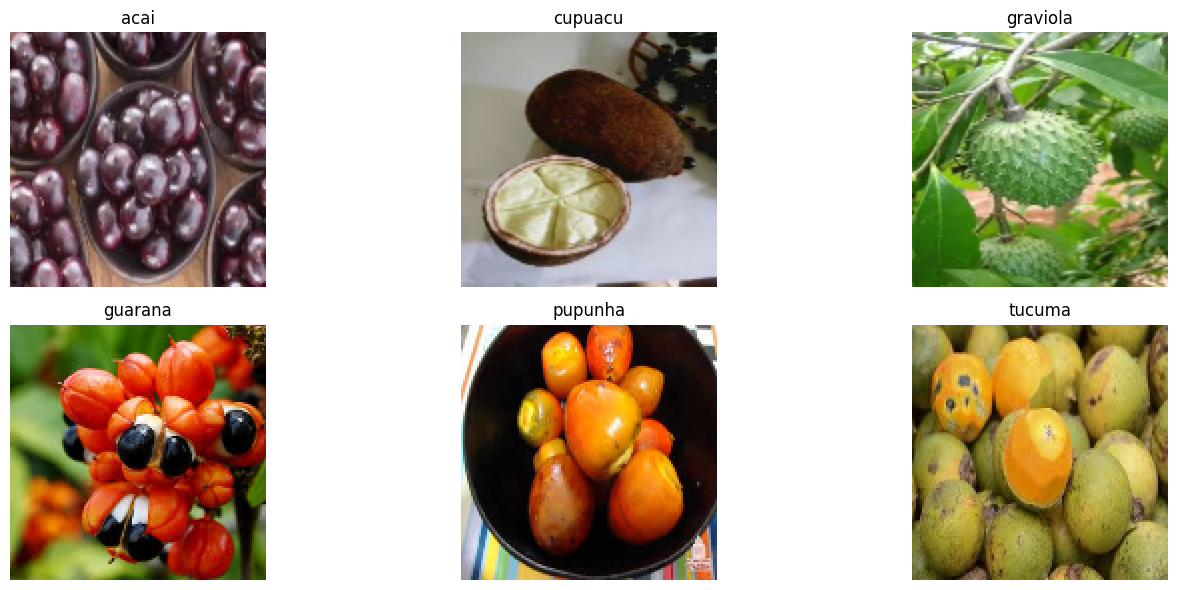

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

selected_images = []
labels = []

# Loop through each class and load a random image
for cls in classes:
    class_path = os.path.join(train_dir, cls)
    images = os.listdir(class_path)
    random.shuffle(images)
    random_image = images[0]
    img_path = os.path.join(class_path, random_image)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img = cv2.resize(img, (128, 128))  # Resize image to (128, 128)
    selected_images.append(img)
    labels.append(cls)

# Set up the plot grid
fig, axes = plt.subplots(nrows=2, ncols=len(selected_images) // 2, figsize=(15, 6))
axes = axes.flatten()

# Display images in a grid
for i, img in enumerate(selected_images):
    axes[i].imshow(img)
    axes[i].set_title(labels[i])
    axes[i].axis("off")

plt.tight_layout()
plt.show()


**What did you Observe?**

I observed images in a 2xN layout, where each image is randomly selected from different classes. It's quite interesting because every time I run the code, the images change due to the random selection, adding a sense surprise. It's exciting to see the different images each time.

**2)**
Check for Corrupted Image:

In [ ]:
from PIL import Image

corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            print(f"Removed corrupted image: {img_path}")
            corrupted_images.append(img_path)
            os.remove(img_path)

if not corrupted_images:
    print("No corrupted images found.")

No corrupted images found.


Yes, the expected output was correct, i didnt find any corrupted image.

**Task 2: Loading and Preprocessing Image Data in keras:**

In [ ]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2
seed = 123

# Normalize images
rescale = tf.keras.layers.Rescaling(1./255)

# Load training data
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

# Load validation data
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

# Apply rescaling
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


**Task 3 - Implement a CNN with Convolutional Architecture and Fully Connected Network Architecture**

In [ ]:
num_classes = len(classes)

model = keras.Sequential([
    layers.Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Task 4: Compile the Model**

In [ ]:
# Compile Model
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

**Task 5: Train the Model**

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_loss"),
    EarlyStopping(patience=10, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=callbacks
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.1655 - loss: 1.7900

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 607ms/step - accuracy: 0.1623 - loss: 1.7891 - val_accuracy: 0.1667 - val_loss: 1.8349
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 517ms/step - accuracy: 0.2235 - loss: 1.7694 - val_accuracy: 0.2222 - val_loss: 1.9048
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 425ms/step - accuracy: 0.2756 - loss: 1.7445 - val_accuracy: 0.1667 - val_loss: 1.8959
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 558ms/step - accuracy: 0.3260 - loss: 1.6849 - val_accuracy: 0.1667 - val_loss: 1.8903
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 713ms/step - accuracy: 0.4262 - loss: 1.5864 - val_accuracy: 0.1111 - val_loss: 1.9918
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 433ms/step - accuracy: 0.3238 - loss: 1.5413 - val_accuracy: 0.1667 - val_loss: 1.8623
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 429ms/step - accuracy: 0.4705 - loss: 1.3354 - val_accuracy: 0.2222 - val_loss: 2.0392
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 422ms/step - accuracy: 0.5560 - loss: 1.3286 - val_accuracy: 0.1111 - val_loss: 2.1

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 534ms/step - accuracy: 0.4175 - loss: 1.2466 - val_accuracy: 0.1667 - val_loss: 1.6791
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 554ms/step - accuracy: 0.5091 - loss: 1.1250 - val_accuracy: 0.1111 - val_loss: 2.2459
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 738ms/step - accuracy: 0.4883 - loss: 1.1592 - val_accuracy: 0.1667 - val_loss: 1.8050
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 435ms/step - accuracy: 0.7114 - loss: 0.8020 - val_accuracy: 0.2222 - val_loss: 2.7591
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 417ms/step - accuracy: 0.6736 - loss: 0.8634 - val_accuracy: 0.3889 - val_loss: 1.8836
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 493ms/step - accuracy: 0.7452 - loss: 0.9347 - val_accuracy: 0.2222 - val_loss: 2.1766
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 421ms/step - accuracy: 0.7912 - loss: 0.5510 - val_accuracy: 0.2222 - val_loss: 3.0438
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 692ms/step - accuracy: 0.5178 - loss: 1.3953 - val_accuracy: 0.1667 - val_lo

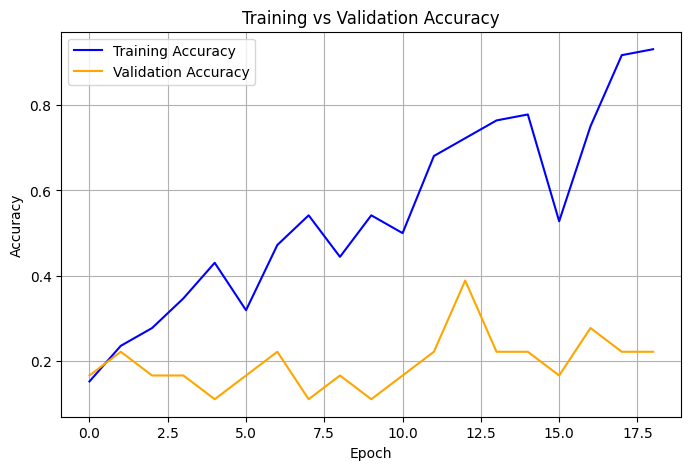

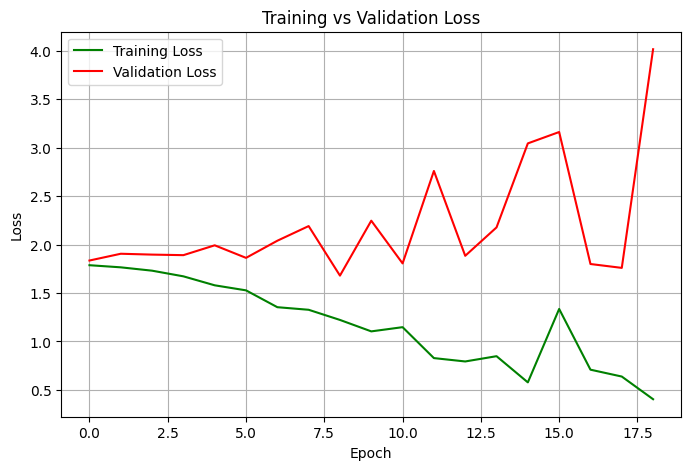

In [ ]:
#Training and validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#Training and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='green')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


**Task 6: Evaluate the Model**

In [ ]:
# Load test data from the test_dir
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical',  # Because I used categorical_crossentropy
    shuffle=False
)

# Normalize test images
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.2000 - loss: 1.5544
Test Accuracy: 0.2000
Test Loss: 1.5544


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,232,910 (16.15 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,116,456 (8.07 MB)

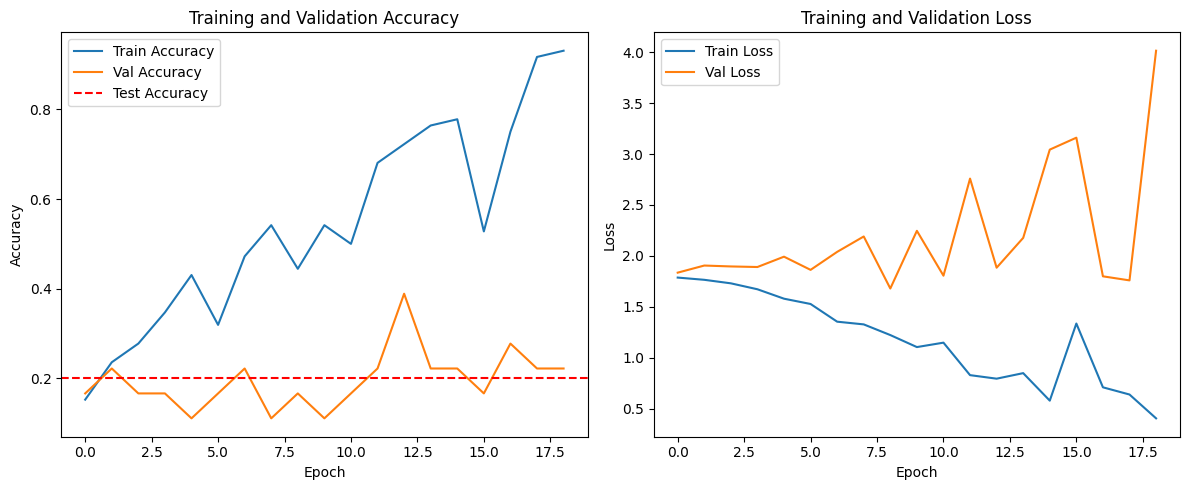

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.axhline(y=test_acc, color='r', linestyle='--', label='Test Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


**Task 7: Save and Load the Model**

In [ ]:
# Save the trained model
model.save("final_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
# Load the saved model
loaded_model = keras.models.load_model("final_model.h5")
print("Model loaded successfully!")

# Re-evaluate
test_loss, test_acc = loaded_model.evaluate(test_ds)
print(f"Reloaded Model - Test Accuracy: {test_acc:.4f}")

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step - accuracy: 0.2000 - loss: 1.5544
Reloaded Model - Test Accuracy: 0.2000


**Task 8: Predictions and Classification Report**

In [ ]:
# Reload test dataset to get class names
raw_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=False
)

# Extract class names from raw dataset before applying rescale
class_names = raw_test_ds.class_names

# Normalize for predictions
test_ds = raw_test_ds.map(lambda x, y: (rescale(x), y))


Found 30 files belonging to 6 classes.


In [ ]:
# Predict
pred_probs = model.predict(test_ds)
y_pred = np.argmax(pred_probs, axis=1)

# Get true labels
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_true = np.argmax(y_true, axis=1)

# Classification Report
from sklearn.metrics import classification_report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
Classification Report:
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.21      0.60      0.32         5
    graviola       0.00      0.00      0.00         5
     guarana       0.33      0.20      0.25         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.20      0.40      0.27         5

    accuracy                           0.20        30
   macro avg       0.12      0.20      0.14        30
weighted avg       0.12      0.20      0.14        30



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Confusion Matrix to visually understand the model performance**

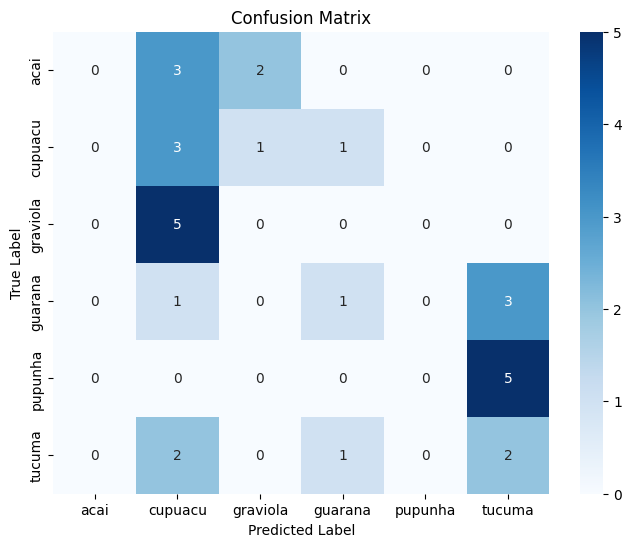

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows how well the model guessed the fruit types. If the model was perfect, all the correct guesses would line up in a straight line down the middle. Here, it did a great job with graviola and pupunha it got all of them right. But it totally missed acai every time and confused it with other fruits. It also mixed up guarana and tucuma a few times. So, in simple terms: the model is good at some fruits but still gets quite a few wrong, especially acai.